# outlier detection and Handling
### Outlier handling :-
- Trimming
- Capping
### Outlier detection :-
- Z-score method (if dist. -> perfectly normal)
- IQR method (if dist. -> skewed)
- percentile method (not sure)
- Winsorization


In [74]:
import numpy as np
import pandas as pd
import seaborn as sns

In [75]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

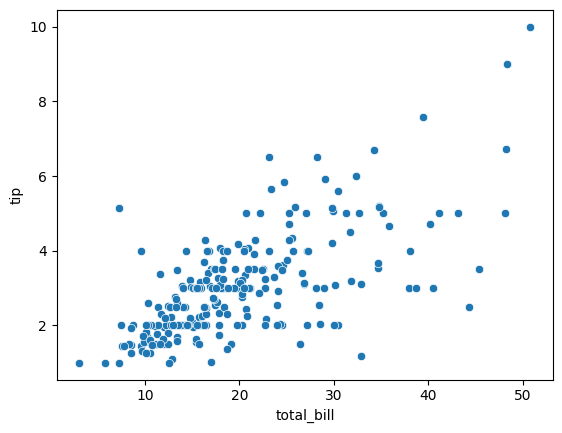

In [76]:
sns.scatterplot(x="total_bill", y="tip", data=df)

C:\Windows\Temp\ipykernel_10512\2943580123.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["total_bill"])


<Axes: xlabel='total_bill', ylabel='Density'>

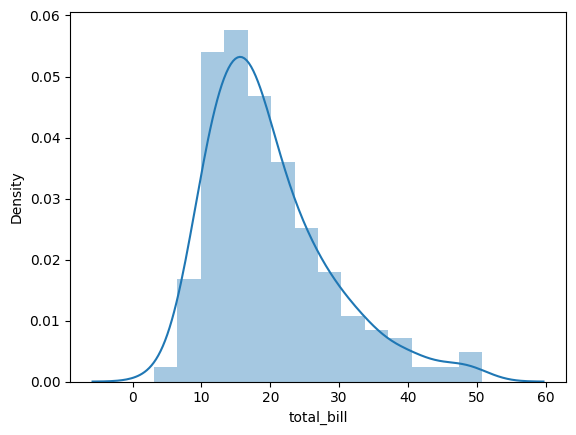

In [77]:
sns.distplot(df["total_bill"])

## Z-score method
> since total bill looks silghtly normal

In [78]:
max = df['total_bill'].mean() + 3*df['total_bill'].std()
min = df['total_bill'].mean() - 3*df['total_bill'].std()
print('max:', max)
print('min:', min)

max: 46.49317848752139
min: -6.921293241619747


In [79]:
df[df['total_bill'] > max]
# since min is negative and total_bill cannot be negative, we will not consider min value for outlier detection. 
# 
# Hence, we will only consider max value for outlier detection. We can also use IQR method for out

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4


In [80]:
df.shape

(244, 7)

### trimming 
> since. 4 rows/samples are outlier, we can simply remove them

Also, we can calculate the Z-score, and detect outliers :-
$$
z = (X_i - mean) / std
$$

In [81]:
new_df = df[df['total_bill'] < max]
new_df.shape

# not removing min value outlier, cuz they aren't Outliers (logically)

(240, 7)

### Capping
> using np.where

In [82]:
# for i in df['total_bill']:
#     if i > max:
#         i = max


df['total_bill'] = np.where(df['total_bill'] > max, max, df['total_bill'])
df[df['total_bill'] > max]

,total_bill,tip,sex,smoker,day,time,size


In [83]:
df[df['total_bill'] > max]

,total_bill,tip,sex,smoker,day,time,size


## IQR based
> using when dist. -> Skewed

.percentile(0.25)


C:\Windows\Temp\ipykernel_10512\4235560333.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['tip'])


<Axes: xlabel='tip', ylabel='Density'>

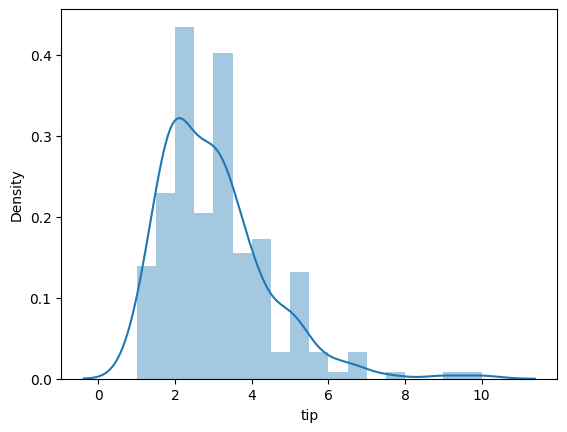

In [84]:
sns.distplot(df['tip'])

In [85]:
df['tip'].skew()

np.float64(1.4654510370979401)

<Axes: ylabel='tip'>

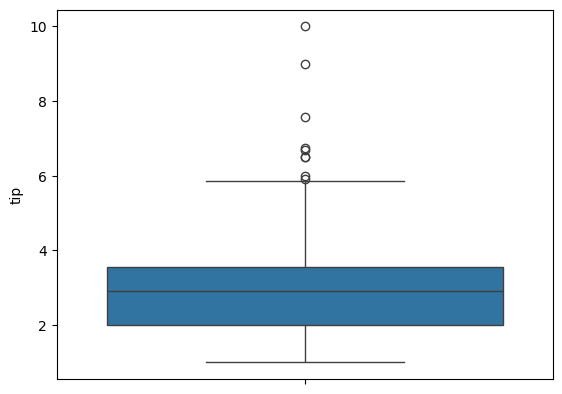

In [86]:
sns.boxplot(df['tip'])
# as you can see there are some outliers already

In [87]:
iqr = df['tip'].quantile(0.75) - df['tip'].quantile(0.25)

max_tip = df['tip'].quantile(0.75) + 1.5*iqr
min_tip = df['tip'].quantile(0.25) - 1.5*iqr

print ('max_tip:', max_tip)
print ('min_tip:', min_tip)

max_tip: 5.90625
min_tip: -0.34375


> Now since min is negative (not possible) => ignore it 
### trimming

In [88]:
df.shape

(244, 7)

In [89]:
df[df['tip'] > max_tip]

,total_bill,tip,sex,smoker,day,time,size
23,39.420000,7.58,Male,No,Sat,Dinner,4
47,32.400000,6.00,Male,No,Sun,Dinner,4
59,46.493178,6.73,Male,No,Sat,Dinner,4
141,34.300000,6.70,Male,No,Thur,Lunch,6
170,46.493178,10.00,Male,Yes,Sat,Dinner,3
183,23.170000,6.50,Male,Yes,Sun,Dinner,4
212,46.493178,9.00,Male,No,Sat,Dinner,4
214,28.170000,6.50,Female,Yes,Sat,Dinner,3
239,29.030000,5.92,Male,No,Sat,Dinner,3


In [92]:
tip_df = df.copy()
tip_df = tip_df[tip_df['tip'] < max_tip]

In [93]:
tip_df.shape

(235, 7)

# capping

In [97]:
df['tip_cap_iqr'] = np.where(df['tip'] > max_tip, max_tip, df['tip'])
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size,tip_cap_iqr
226,10.090000,2.00,Female,Yes,Fri,Lunch,2,2.00000
170,46.493178,10.00,Male,Yes,Sat,Dinner,3,5.90625
190,15.690000,1.50,Male,Yes,Sun,Dinner,2,1.50000
17,16.290000,3.71,Male,No,Sun,Dinner,3,3.71000
214,28.170000,6.50,Female,Yes,Sat,Dinner,3,5.90625


# percentile and winsorization
> In percentile, the capping is known as winsorization
---
> because we are replcing the outliers wtih second max value